# Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset

In [4]:
df = pd.read_csv("/kaggle/input/datasets/nalisha/student-exam-scores-analysis-ipyn/student_exam_scores.csv")

print("="*50)
print("Dataset Shape")
print(df.shape)

print("\n" + "="*50)
print("First 5 Rows")
print(df.head())

print("\n" + "="*50)
print("Column Names")
print(df.columns.tolist())

Dataset Shape
(200, 6)

First 5 Rows
  student_id  hours_studied  sleep_hours  attendance_percent  previous_scores  \
0       S001            8.0          8.8                72.1               45   
1       S002            1.3          8.6                60.7               55   
2       S003            4.0          8.2                73.7               86   
3       S004            3.5          4.8                95.1               66   
4       S005            9.1          6.4                89.8               71   

   exam_score  
0        30.2  
1        25.0  
2        35.8  
3        34.0  
4        40.3  

Column Names
['student_id', 'hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores', 'exam_score']


# Basic Information

In [5]:
print("\n" + "="*50)
print("Dataset Info")
print(df.info())

print("\n" + "="*50)
print("Statistical Summary")
print(df.describe())


Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          200 non-null    object 
 1   hours_studied       200 non-null    float64
 2   sleep_hours         200 non-null    float64
 3   attendance_percent  200 non-null    float64
 4   previous_scores     200 non-null    int64  
 5   exam_score          200 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.5+ KB
None

Statistical Summary
       hours_studied  sleep_hours  attendance_percent  previous_scores  \
count     200.000000   200.000000          200.000000       200.000000   
mean        6.325500     6.622000           74.830000        66.800000   
std         3.227317     1.497138           14.249905        15.663869   
min         1.000000     4.000000           50.300000        40.000000   
25%         3.500000     5.30000

# Missing Values

In [6]:
print("\n" + "="*50)
print("Missing Values")
print(df.isnull().sum())



Missing Values
student_id            0
hours_studied         0
sleep_hours           0
attendance_percent    0
previous_scores       0
exam_score            0
dtype: int64


# Duplicate Values

In [7]:
print("\n" + "="*50)
print("Duplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


# Correlation Analysis

In [8]:

numeric_df = df.drop(columns=["student_id"])

print("\n" + "="*50)
print("Correlation Matrix")
print(numeric_df.corr())



Correlation Matrix
                    hours_studied  sleep_hours  attendance_percent  \
hours_studied            1.000000     0.077864           -0.031311   
sleep_hours              0.077864     1.000000            0.000572   
attendance_percent      -0.031311     0.000572            1.000000   
previous_scores          0.069078    -0.194251            0.051958   
exam_score               0.776751     0.188222            0.225713   

                    previous_scores  exam_score  
hours_studied              0.069078    0.776751  
sleep_hours               -0.194251    0.188222  
attendance_percent         0.051958    0.225713  
previous_scores            1.000000    0.431105  
exam_score                 0.431105    1.000000  



# Visualization

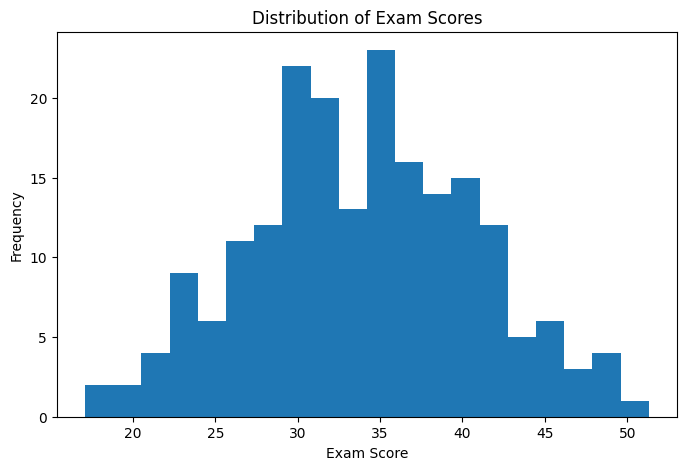

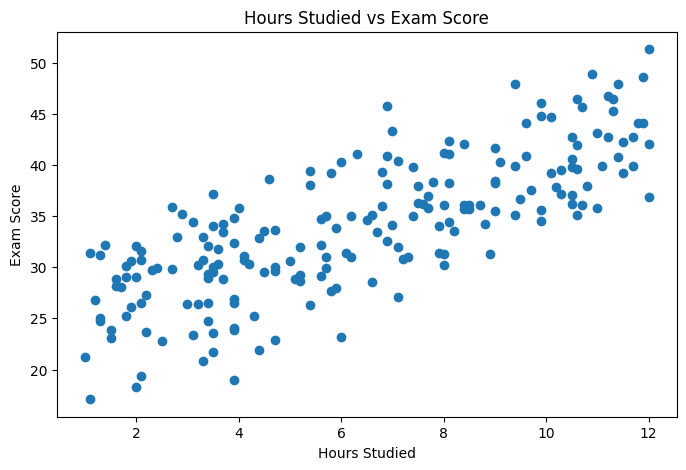

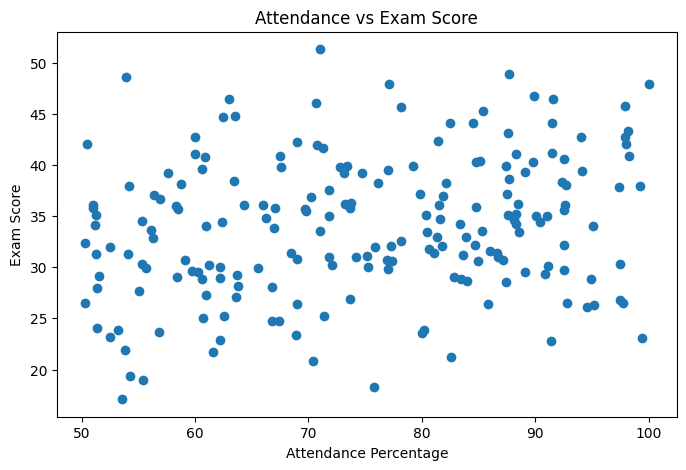

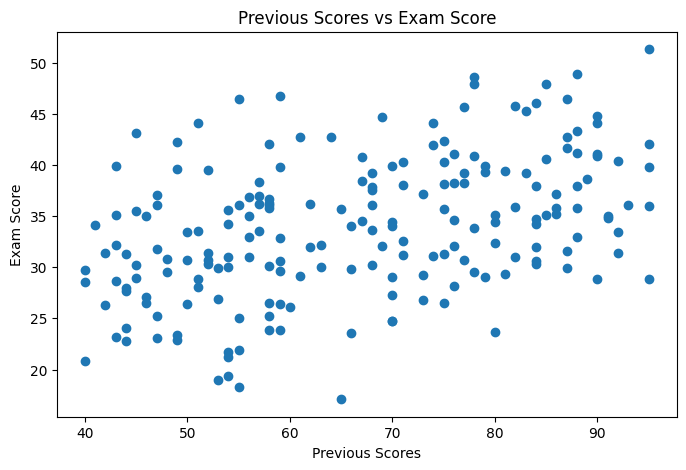

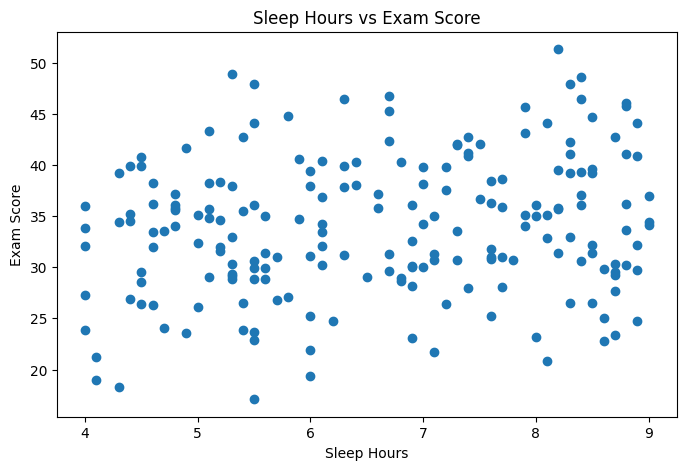

In [9]:

# Exam Score Distribution
plt.figure(figsize=(8,5))
plt.hist(df["exam_score"], bins=20)
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.show()

# Hours Studied vs Exam Score
plt.figure(figsize=(8,5))
plt.scatter(df["hours_studied"], df["exam_score"])
plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.show()

# Attendance vs Exam Score
plt.figure(figsize=(8,5))
plt.scatter(df["attendance_percent"], df["exam_score"])
plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance Percentage")
plt.ylabel("Exam Score")
plt.show()

# Previous Scores vs Exam Score
plt.figure(figsize=(8,5))
plt.scatter(df["previous_scores"], df["exam_score"])
plt.title("Previous Scores vs Exam Score")
plt.xlabel("Previous Scores")
plt.ylabel("Exam Score")
plt.show()

# Sleep Hours vs Exam Score
plt.figure(figsize=(8,5))
plt.scatter(df["sleep_hours"], df["exam_score"])
plt.title("Sleep Hours vs Exam Score")
plt.xlabel("Sleep Hours")
plt.ylabel("Exam Score")
plt.show()


# Feature Selection


In [10]:

X = df[[
    "hours_studied",
    "sleep_hours",
    "attendance_percent",
    "previous_scores"
]]

y = df["exam_score"]



# Train-Test Split

In [11]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Model Training

In [12]:

model = LinearRegression()

model.fit(X_train, y_train)


LinearRegression()

# Prediction


In [13]:

y_pred = model.predict(X_test)

# Model Evaluation

In [14]:

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n" + "="*50)
print("MODEL PERFORMANCE")
print("="*50)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")


MODEL PERFORMANCE
MAE  : 2.31
MSE  : 7.76
RMSE : 2.79
R² Score : 0.8537



# Feature Importance

In [15]:

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

print("\n" + "="*50)
print("Feature Importance")
print(feature_importance)


Feature Importance
              Feature  Coefficient
0       hours_studied     1.549341
1         sleep_hours     0.884156
3     previous_scores     0.183034
2  attendance_percent     0.108949



# Actual vs Predicted

In [16]:
comparison = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": y_pred
})

print("\n" + "="*50)
print("Actual vs Predicted")
print(comparison.head(10))



Actual vs Predicted
   Actual Score  Predicted Score
0          28.7        28.886072
1          34.1        29.680421
2          34.5        35.311956
3          29.5        31.180448
4          36.1        39.448943
5          46.4        41.691583
6          23.9        23.969183
7          45.3        45.722509
8          44.8        41.652932
9          31.8        27.476157



# Conclusion


1. **Students** who study more hours generally achieve higher exam scores.
2. **Previous** academic performance strongly influences exam results.
3. **Attendance** percentage has a positive impact on performance.
4. **Sleep hours** contribute to performance but less than study time and previous scores.
5. The **Linear Regression** model successfully predicts exam scores using student-related factors.


In [17]:
import joblib
joblib.dump(model, "student_exam_model.pkl")

['student_exam_model.pkl']

In [18]:
print(df.columns.tolist())

['student_id', 'hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores', 'exam_score']


In [19]:
df.describe()

,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,6.325500,6.622000,74.830000,66.800000,33.955000
std,3.227317,1.497138,14.249905,15.663869,6.789548
min,1.000000,4.000000,50.300000,40.000000,17.100000
25%,3.500000,5.300000,62.200000,54.000000,29.500000
50%,6.150000,6.700000,75.250000,67.500000,34.050000
75%,9.000000,8.025000,87.425000,80.000000,38.750000
max,12.000000,9.000000,100.000000,95.000000,51.300000


In [24]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)
rf.fit(X_train, y_train)

predictions = rf.predict(X_test)

print("R² Score:", r2_score(y_test, predictions))
print("MAE:", mean_absolute_error(y_test, predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, predictions)))

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

R² Score: 0.8065476288176398
MAE: 2.824023000000001
RMSE: 3.20414367403913
hours_studied         0.657591
previous_scores       0.179613
attendance_percent    0.102086
sleep_hours           0.060710
dtype: float64


In [22]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':[100,200,500],
    'max_depth':[5,10,15,None],
    'min_samples_split':[2,5,10]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=5,
    scoring='r2'
)

grid.fit(X_train,y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 500}
0.7119924970315571
